In [2]:
import re
import os
import time
import spacy
import numpy as np
import string
import regex
import sqlite3
import inflect
import pickle
import threading
import pandas as pd
from tqdm import tqdm
from os import listdir
from pandas import DataFrame
from taxonerd import TaxoNERD
from os.path import isfile, join
from IPython.display import clear_output
from rich.console import Console
from itertools import islice
from spacy.util import filter_spans
from spacy.tokens import Token, Doc, Span
from typing import List, Dict, Tuple, Set, Optional, Union, Literal

In [17]:
conn = sqlite3.connect("COL.db")
# LUCIDA CONSOL

In [3]:
inflector = inflect.engine()

In [18]:
inflector.singular_noun('red-shits')

'red-shit'

In [18]:
def load_file(name, load):
    output = None
    if os.path.exists(name):
        with open(name, "rb") as file:
            output = pickle.load(file)
    else:
        output = load()
        with open(name, "wb") as file:
            pickle.dump(output, file)
    return output

In [19]:
def load_vernacular_names():
    df = pd.read_sql("""
        SELECT "col:name" 
        FROM VernacularName 
        WHERE "col:language" = 'eng'
    """, conn)
    return set([name.lower() for name in df["col:name"].tolist() if name])

vernacular_names = load_file("VernacularNames.pickle", load_vernacular_names)
print(f"# of Names: {len(vernacular_names)}")

# of Names: 184589


In [20]:
def load_scientific_names():
    df = pd.read_sql("""
        SELECT "col:scientificName" 
        FROM NameUsage
    """, conn)
    return set([name.lower() for name in df["col:scientificName"].tolist() if name])

scientific_names = load_file("ScientificNames.pickle", load_scientific_names)
print(f"# of Names: {len(scientific_names)}")

# of Names: 7648104


In [21]:
def load_genus_names():
    df = pd.read_sql("""
        SELECT "col:genus" 
        FROM NameUsage
    """, conn)
    return set([name.lower() for name in df["col:genus"].tolist() if name])

genus_names = load_file("GenusNames.pickle", load_genus_names)
print(f"# of Names: {len(genus_names)}")

# of Names: 229790


In [22]:
def re_is_genus(name: str, flags: int = 0) -> bool:
    return regex.match(r"^\p{Lu}\p{Ll}+$", name, flags)

In [23]:
def re_is_scientific_name(name: str, flags: int = 0) -> bool:
    return regex.match(r"^\p{Lu}\p{Ll}+\s\p{Ll}+$", name, flags)

In [24]:
def re_is_scientific_name_abbrev(name: str, flags: int = 0) -> Union[str, Tuple[str, str]]:
    if not regex.match(r"^\p{Lu}\.\s\p{Ll}+$", name, flags):
        return False
    return name.split()

In [25]:
def abbreviate_scientific_name(name: str) -> Union[bool, str]:
    if not re_is_scientific_name(name, flags=re.IGNORECASE):
        return False
    name = name.split()
    return f"{name[0][0].upper()}. {name[1].lower()}"

In [26]:
def load_mapped_names():
    df = pd.read_sql("""
        SELECT * 
        FROM JoinedTable
    """, conn)
    df['GenusLC'] = df['Genus'].str.lower()
    df['ScientificNameLC'] = df['ScientificName'].str.lower()
    df['VernacularNameLC'] = df['VernacularName'].str.lower()
    df['GenericNameLC0'] = df['GenericName'].str.lower().str[0]
    df['SpecificEpithetLC'] = df['SpecificEpithet'].str.lower()
    return df

mapped_names_df = load_file("MappedNames.pickle", load_mapped_names)

In [27]:
def load_scientific_names_map():
    m = {}
    
    for i, row in mapped_names_df.iterrows():
        if row.ScientificName:
            text = row.ScientificName.lower()
            if text not in m:
                m[text] = set()
            m[text].add(row.VernacularName)
            m[text].add(row.Genus)
    
        abbrev = abbreviate_scientific_name(row.ScientificName)
        if abbrev:
            text = abbrev.lower()
            if text not in m:
                m[text] = set()
            m[text].add(row.VernacularName)
            m[text].add(row.Genus)

    return m

scientific_names_map = load_file("ScientificNamesMap.pickle", load_scientific_names_map)

In [28]:
def load_vernacular_names_map():
    m = {}
    
    for i, row in mapped_names_df.iterrows():
        if row.VernacularName:
            text = row.VernacularName.lower()
            if text not in m:
                m[text] = set()
            m[text].add(row.ScientificName)
            m[text].add(row.Genus)
    
    return m

vernacular_names_map = load_file("VernacularNamesMap.pickle", load_vernacular_names_map)

In [29]:
def load_genus_names_map():
    m = {}

    for i, row in mapped_names_df.iterrows():
        if row.Genus:
            text = row.Genus.lower()
            if text not in m:
                m[text] = set()
            m[text].add(row.VernacularName)
            m[text].add(row.ScientificName)

    return m

genus_names_map = load_file("GenusNamesMap.pickle", load_genus_names_map)

In [30]:
def scientific_name_exists(name: str) -> list[str]:
    return name.lower() in scientific_names

In [31]:
def vernacular_name_exists(name: str) -> list[str]:
    return name.lower() in vernacular_names

In [32]:
def genus_exists(name: str) -> list[str]:
    return name.lower() in genus_names

In [33]:
def scientific_name_substitutions(name: str) -> list[str]:
    output = scientific_names_map.get(name.lower(), [])
    return output

In [34]:
def vernacular_name_substitutions(name: str) -> list[str]:
    output = vernacular_names_map.get(name.lower(), [])
    return output

In [35]:
def genus_substitutions(name: str) -> list[str]:
    output = genus_names_map.get(name.lower(), [])
    return output

In [36]:
def expand_unit(doc: Doc, il_unit: int, ir_unit: int, il_boundary: int, ir_boundary: int, speech: List[str] = [], literals: List[str] =[], include: bool = True, direction: str = 'BOTH', verbose: bool = False):
    UNIT = doc[il_unit:ir_unit+1]
        
    if il_unit > ir_unit:
        print(f"Error: il_unit of {il_unit} greater than ir_unit of {ir_unit}")
        return None
    
    if direction in ['BOTH', 'LEFT'] and il_boundary > il_unit:
        print(f"Error: il_unit of {il_unit} less than il_boundary of {il_boundary}")
        return None
    
    if direction in ['BOTH', 'RIGHT'] and ir_boundary < ir_unit:
        print(f"Error: ir_unit of {ir_unit} greater than ir_boundary of {ir_boundary}")
        return None
    
    # Move Left
    if direction in ['BOTH', 'LEFT']:
        # The indices are inclusive, therefore, when 
        # the condition fails, il_unit will be equal
        # to il_boundary.
        while il_unit > il_boundary:
            # We assume that the current token is allowed,
            # and look to the token to the left.
            l_token = doc[il_unit-1]

            # If the token is invalid, we stop expanding.
            in_set = l_token.pos_ in speech or l_token.lower_ in literals

            # Case 1: include=False, in_set=True
            # If we're not meant to include the defined tokens, and the
            # current token is in that set, we stop expanding.
            # Case 2: include=True, in_set=False
            # If we're meant to include the defined tokens, and the current
            # token is not in that set, we stop expanding.
            # Case 3: include=in_set
            # If we're meant to include the defined tokens, and the current
            # token is in that set, we continue expanding. If we're not meant
            # to include the defined tokens, and the current token is not
            # in that set, we continue expanding.
            if include ^ in_set:
                break
            
            # Else, the left token is valid, and
            # we continue to expand.
            il_unit -= 1

    # Move Right
    if direction in ['BOTH', 'RIGHT']:
        # Likewise, when the condition fails,
        # ir_unit will be equal to the ir_boundary.
        # The ir_boundary is also inclusive.
        while ir_unit < ir_boundary:
            # Assuming that the current token is valid,
            # we look to the right to see if we can
            # expand.
            r_token = doc[ir_unit+1]

            # If the token is invalid, we stop expanding.
            in_set = r_token.pos_ in speech or r_token.lower_ in literals
            if include ^ in_set:
                break

            # Else, the token is valid and
            # we continue.
            ir_unit += 1

    assert il_unit >= il_boundary and ir_unit <= ir_boundary
    expanded_unit = doc[il_unit:ir_unit+1]

    if verbose and VERBOSE_LEVEL >= 1:
        print(f"Expanded Unit of '{UNIT}': {expanded_unit}")
    
    return expanded_unit

In [37]:
def contract_unit(doc: Doc, il_unit: int, ir_unit: int, speech: List[str] = [], literals: List[str] =[], include: bool =True, direction: str = 'BOTH', verbose: bool =False):
    UNIT = doc[il_unit:ir_unit+1]
    
    if il_unit > ir_unit:
        print(f"Error: il_unit of {il_unit} greater than ir_unit of {ir_unit}")
        return None
    
    # Move Right
    if direction in ['BOTH', 'LEFT']:
        while il_unit < ir_unit:
            # We must check if the current token is not allowed. If it's
            # not allowed, we contract (remove).
            token = doc[il_unit]

            # include = True means that we want the tokens that match
            # the speech and/or literals in the contracted unit.
            
            # include = False means that we don't want the tokens that
            # match the speech and/or literals in the contracted unit.
            
            # Case 1: include = True, in_set = True
            # We have a token that's meant to be included in the set.
            # However, we're contracting, which means we would end up
            # removing the token if we continue. Therefore, we break.
            
            # Case 2: include = False, in_set = False
            # We have a token that's not in the set which defines the
            # tokens that aren't meant to be included. Therefore, we 
            # have a token that is meant to be included. If we continue,
            # we would end up removing this token. Therefore, we break.
            
            # Default:
            # If we have a token that's in the set (in_set=True) of
            # tokens we're not supposed to include in the contracted 
            # unit (include=False), we need to remove it. Likewise, if
            # we have a token that's not in the set (in_set=False) of
            # tokens to include in the contracted unit (include=True),
            # we need to remove it.
            
            in_set = token.pos_ in speech or token.lower_ in literals
            if include == in_set:
                break

            # The token is valid, thus we continue.
            il_unit += 1

    # Move Left      
    if direction in ['BOTH', 'RIGHT']:
        while ir_unit > il_unit:
            token = doc[ir_unit]

            # The token is invalid and we
            # stop contracting.
            in_set = token.pos_ in speech or token.lower_ in literals
            if include == in_set:
                break

            # The token is valid and we continue.
            ir_unit -= 1

    assert il_unit <= ir_unit
    contracted_unit = doc[il_unit:ir_unit+1]

    if verbose and VERBOSE_LEVEL >= 1:
        print(f"Contracted Unit of '{UNIT}': {contracted_unit}")
    
    return contracted_unit

In [38]:
def break_text(text: str, return_type: Literal["Flat", "TextFlat", "Text", "TextAdd"]) -> Union[List[List[Tuple[int, int]]], List[Tuple[int, int]], List[List[str]], List[str]]:
    enclosures = {
        "(":")", 
        "[":"]",
        "{":"}"
    }
    
    # This contains the text that's not inside
    # any enclosure.
    base = []

    # This contains the text that's inside
    # an enclosure.
    groups = []
    
    # This is used for building groups, which can
    # have a nested structure.
    stacks = []
    
    # These are the pairs of characters that
    # define the enclosure (parenthetical).
    openers = list(enclosures.keys())
    closers = list(enclosures.values())
    
    # This contains the opening characters of the groups 
    # that are currently open (e.g. '(', '['). We use it 
    # so that we know whether to open or close a group.
    opened = []
    
    for i, char in enumerate(text):
        # Open Group
        if char in openers:
            stacks.append([])
            opened.append(char)
        # Close Group
        elif opened and char == enclosures.get(opened[-1], ""):
            groups.append(stacks.pop())
            opened.pop()
        # Add to Group
        elif opened:
            stacks[-1].append(i)
        # Add to Base Text
        else:
            base.append(i)
    
    # We close the remaining groups that have not
    # been closed.
    while stacks:
        groups.append(stacks.pop())
        
    # Cluster Groups' Indices
    # A list in the lists of indices (where each list represents a group of text) could have 
    # an interruption (e.g. [0, 1, 2, 10, 15]) because of a parenthetical. So, we cluster the
    # indices in each list to make the output more useful (e.g. [(0, 3), (10, 16)]). As you
    # can see, we've adjusted some indices for ease-of-use.
    lists_of_indices = [*groups, base]        
    lists_of_clustered_indices = []

    for list_of_indices in lists_of_indices:
        if not list_of_indices:
            continue

        # We start off with a single cluster that is made up of the
        # first index. If the next index follows the first index, 
        # we continue the cluster. If it doesn't, we create a new cluster.
        clustered_indices = [[list_of_indices[0], list_of_indices[0] + 1]]
        
        for index in list_of_indices[1:]:
            if clustered_indices[-1][1] == index:
                clustered_indices[-1][1] = index + 1
            else:
                clustered_indices.append([index, index + 1])

        # Add Clustered Indices
        lists_of_clustered_indices.append(clustered_indices)

    if return_type in ["Flat", "TextFlat"]:
        flat_clusters = []
        # We are placing each cluster of indices into one list.
        # This removes the context of the larger parenthetical,
        # but the context may be cumbersome instead of useful.
        for list_of_clustered_indices in lists_of_clustered_indices:
            for clustered_indices in list_of_clustered_indices:
                flat_clusters.append(clustered_indices)
        lists_of_clustered_indices = flat_clusters
    
        if return_type == "TextFlat":
            return [text[cluster[0]:cluster[1]] for cluster in lists_of_clustered_indices]
    
    if return_type in ["Text", "TextAdd"]:
        lists_of_clustered_text = [[text[cluster[0]:cluster[1]] for cluster in clusters] for clusters in lists_of_clustered_indices]
        if return_type == "TextAdd":
            return ["".join(list_of_clustered_text) for list_of_clustered_text in lists_of_clustered_text]
        return lists_of_clustered_text

    return lists_of_clustered_indices

In [39]:
def clean_text(text: str) -> str:
    # 1. Delete Inside and Outside Space
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"\s+([?.!,])", r"\1", text)
    text = text.strip()

    # 2. Delete Outside Non-Letters
    while text:
        start_len = len(text)
        # Remove Leading Non-Alphanumeric Character
        if text and not text[0].isalnum():
            text = text[1:]
        # Remove Trailing Non-Alphanumeric Character
        if text and not text[-1].isalnum():
            text = text[:-1]
        # No Changes Made
        if start_len == len(text):
            break
    
    return text

In [40]:
inflector = inflect.engine()

In [41]:
CACHE_PLURALIZE_TEXT = {}

def pluralize_text(text: str) -> str:
    if text in CACHE_PLURALIZE_TEXT:
        return CACHE_PLURALIZE_TEXT[text]
    
    split_text = text.split()
    plural_end = inflector.plural_noun(split_text[-1])

    if not plural_end:
        CACHE_PLURALIZE_TEXT[text] = False
        return False

    split_text[-1] = plural_end
    plural_text = " ".join(split_text)

    CACHE_PLURALIZE_TEXT[text] = plural_text
    return plural_text

In [42]:
CACHE_SINGULARIZE_TEXT = {}

def singularize_text(text: str) -> str:
    if text in CACHE_SINGULARIZE_TEXT:
        return CACHE_SINGULARIZE_TEXT[text]
    
    split_text = text.split()
    singular_end = inflector.singular_noun(split_text[-1])
    
    if not singular_end:
        CACHE_SINGULARIZE_TEXT[text] = False
        return False

    split_text[-1] = singular_end
    singular_text = " ".join(split_text)

    CACHE_SINGULARIZE_TEXT[text] = singular_text
    return singular_text

In [139]:
def search_strings_tn(ents: List[Span]) -> List[str]:
    search_strings = []
    
    for ent in ents:
        split_text = break_text(ent.text.lower(), return_type="TextAdd")
        split_text = [clean_text(text) for text in split_text]
        search_strings.extend(split_text)

        for text in split_text:
            if not text or re.search(r"[^\w\s.-]", text):
                continue

            # Add Base Noun
            base = text.split()[-1]
            if not regex.match(r"\w\$.", base):
                search_strings.append(base)

            # Add Singular Version
            s_text = singularize_text(text)
            if s_text:
                search_strings.append(s_text)

            # Add Plural Version
            p_text = pluralize_text(text)
            if p_text:
                search_strings.append(p_text)

    # Remove Duplicates
    search_strings = [*set(search_strings)]
    return search_strings

In [44]:
def find_search_strings_tn(doc: Doc, search_strings: List[str]) -> List[Span]:
    spans = []
    text = doc.text.lower()
    
    for string in search_strings:
        matches = re.finditer(re.escape(string), text, re.IGNORECASE)
        
        for l_char_index, r_char_index, matched_text in [(match.start(), match.end(), match.group()) for match in matches]:
            # The full word must match, not just a substring inside of it.
            # So, if the species we're looking for is "ant", only "ant"
            # will match -- not "pants" or "antebellum". Therefore, the
            # characters to the left and right of the matched string cannot
            # be letters.
            l_char_is_letter = l_char_index > 0 and text[l_char_index-1].isalpha()
            r_char_is_letter = r_char_index < len(text) and text[r_char_index].isalpha()
            
            if l_char_is_letter or r_char_is_letter or not matched_text:
                continue
            
            span = doc.char_span(l_char_index, r_char_index, alignment_mode="expand")
            if not span:
                continue
            
            # Expand Species
            # Let's say there's a word like "squirrel". That's a bit ambiguous. 
            # Is it a brown squirrel, a bonobo? If the species is possibly missing
            # information (like an adjective to the left of it), we should expand
            # in order to get a full picture of the species.
            is_short = len(span) == 1 and span[0].pos_ == "NOUN"
            is_scientific = re_is_scientific_name_abbrev(span.text) or scientific_name_exists(span.text) or genus_exists(span.text)

            # Remove Outer Symbols
            # There are times where a species is identified with a parenthesis
            # nearby. Here, we remove that parenthesis (and any other symbols).
            span = contract_unit(
                doc,
                il_unit=span.start, 
                ir_unit=span.end-1, 
                speech=["PUNCT", "SYM", "DET", "PART"],
                include=False,
                verbose=False
            )
            
            if is_short and not is_scientific:
                span = expand_unit(
                    doc,
                    il_unit=span.start, 
                    ir_unit=span.end-1,
                    il_boundary=0,
                    ir_boundary=len(doc),
                    speech=["ADJ", "PROPN", "NOUN"],
                    literals=["-"],
                    include=True,
                    direction="LEFT",
                    verbose=False
                )

            # Remove Outer Symbols (Again)
            # There are times where a species is identified with a parenthesis
            # nearby. Here, we remove that parenthesis (and any other symbols).
            span = contract_unit(
                doc,
                il_unit=span.start, 
                ir_unit=span.end-1, 
                speech=["PUNCT", "SYM", "DET", "PART"],
                include=False,
                verbose=False
            )
            
            # A species must have a noun or a
            # proper noun. This may help discard
            # bad results.
            letter_found = False
            for token in span:
                if token.pos_ in ["NOUN", "PROPN"]:
                    letter_found = True
                    break

            if not letter_found:
                continue

            if re.search(r"[^\w\s.-]", span.text):
                continue
            # Adding Species
            spans.append(span)

    spans = filter_spans(spans)
    return spans

In [45]:
def find_ents_tn(doc: Doc) -> List[Span]:
    search_strings = search_strings_tn(doc.ents)
    ents = find_search_strings_tn(doc, search_strings)
    return ents

In [46]:
def find_ents_db(doc: Doc, taken: Set[int] = []) -> List[Span]:
    ents = []
        
    cache = set()
    scientific_tokens = set()
    nouns = set(["NOUN", "PROPN", "X"])
        
    # Look for Scientific Names
    # These are in pairs of two, which makes the search easier.
    # The pair of two must contain a noun and follow the capitalization
    # format of scientific names.
    i = 0
    while i < len(doc) - 1:
        if i in taken:
            i += 1
            continue
        
        # Check for Genus
        token = doc[i:i+1]
        if re_is_genus(token.text) and token[0].pos_ in nouns and token.text not in cache and genus_exists(token.text):
            if not re.search(r"[^\w\s.-]", token.text):
                cache.add(token.text)
                ents.append(token)
                scientific_tokens.add(token[0])

        # Check for Scientific Name
        j = i + 1
        if doc[i].pos_ not in nouns and doc[j].pos_ not in nouns:
            i += 1
            continue
        
        span = doc[i:j+1]
        text = span.text
    
        if text in cache:
            ents.append(span)
            scientific_tokens.update(list(span))
            i += 2
        elif re_is_scientific_name(text) and scientific_name_exists(text) and not re.search(r"[^\w\s.-]", text):
            cache.add(text)
            cache.add(abbreviate_scientific_name(text))
            ents.append(span)
            scientific_tokens.update(list(span))
            i += 2
        elif re_is_scientific_name_abbrev(text) and not re.search(r"[^\w\s.-]", text):
            cache.add(text)
            ents.append(span)
            scientific_tokens.update(list(span))
            i += 2
        else:
            i += 1


    # Look for Vernacular Names
    i = len(doc) - 1
    while i >= 0:
        if i in taken:
            i -= 1
            continue
        
        if doc[i].pos_ != "NOUN" or doc[i] in scientific_tokens:
            i -= 1
            continue

        span = doc[i:i+1]
        text = span.text

        if re.search(r"[^\w\s.-]", text):
            i -= 1
            continue
        
        if text in cache or vernacular_name_exists(text):
            cache.add(text)

            # 1. Contract
            span = contract_unit(
                doc,
                il_unit=span.start, 
                ir_unit=span.end-1, 
                speech=["PUNCT", "SYM", "DET", "PART"],
                include=False,
                verbose=False
            )

            # 2. Expand
            span = expand_unit(
                doc,
                il_unit=span.start, 
                ir_unit=span.end-1,
                il_boundary=0,
                ir_boundary=len(doc),
                speech=["ADJ", "PROPN", "NOUN"],
                literals=["-"],
                include=True,
                direction="LEFT",
                verbose=False
            )

            # 3. Contract
            span = contract_unit(
                doc,
                il_unit=span.start, 
                ir_unit=span.end-1, 
                speech=["PUNCT", "SYM", "DET", "PART"],
                include=False,
                verbose=False
            )

            if not re.search(r"[^\w\s.-]", span.text):
                ents.append(span)
        
        i -= 1
    
    ents = filter_spans(ents)
    return ents

In [264]:
def find_ents(doc: Doc) -> List[Span]:
    # Entities Found by TN
    ents_tax = find_ents_tn(doc)

    # Entities Found by DB
    ents_col = find_ents_db(doc)

    # Filter Spans
    ents = filter_spans([*ents_tax, *ents_col])
    ents.sort(key=lambda ent: ent.start)

    # 'Merge' Consecutive Spans
    i = 0
    merged_ents = []
    while i < len(ents) - 1:
        if ents[i].end == ents[i+1].start:
            merged_ent = doc[ents[i].start:ents[i+1].end]
            merged_ents.append(merged_ent)
            ents.pop(i)
            ents.pop(i)
        else:
            i += 1
    ents.extend(merged_ents)
    
    # Clean-Up
    i = 0
    while i < len(ents):
        # These do not count
        if "species" in ents[i].text.lower():
            ents.pop(i)
            continue
        i += 1
    
    return ents

In [48]:
def a_abbreviates_b(span_a: Span, span_b: Span) -> bool:
    if len(span_a) < 2 or len(span_b) < 2:
        return False
    
    text_a = f"{span_a[-2]} {span_a[-1]}"
    text_b = f"{span_b[-2]} {span_b[-1]}"

    if text_a == text_b:
        return True
    
    return text_a == abbreviate_scientific_name(text_b)

In [244]:
CACHE_A_MODIFIES_B = {}

def a_modifies_b(span_a: Span, span_b: Span) -> bool:
    # print("\n\n", span_a, "v.", span_b)
    
    key = (span_a.text.lower(), span_b.text.lower())
    key_rev = (span_b.text.lower(), span_a.text.lower())
    
    if key in CACHE_A_MODIFIES_B:
        return CACHE_A_MODIFIES_B[key]

    # print(span_a, span_b, re.search(rf"\b{span_b.text.lower()}\b", span_a.text.lower()))
    if re.search(rf"\b{span_b.text.lower()}\b", span_a.text.lower()):
        CACHE_A_MODIFIES_B[key] = True
        return True

    # Split A and B by Nouns
    nouns_a = []
    non_nouns_a = []
    for i, token in reversed(list(enumerate(span_a))):
        # print(token, token.pos_)
        if token.pos_ not in ["PROPN", "NOUN"]:
            nouns_a = [*span_a[i+1:]]
            non_nouns_a = [*span_a[:i+1]]
            break

    if not nouns_a and not non_nouns_a and len(span_a):
        nouns_a = [*span_a]

    # print("nouns_a", nouns_a)
    # print("non_nouns_a", non_nouns_a)
    
    nouns_b = []
    non_nouns_b = []
    for i, token in reversed(list(enumerate(span_b))):
        # print(token, token.pos_)
        if token.pos_ not in ["PROPN", "NOUN"]:
            nouns_b = [*span_b[i+1:]]
            non_nouns_b = [*span_b[:i+1]]
            break

    if not nouns_b and not non_nouns_b and len(span_b):
        nouns_b = [*span_b]
        
    # print("nouns_b", nouns_b)
    # print("non_nouns_b", non_nouns_b)
    
    # Base (Ending) Nouns in A
    # base_nouns_a = []
    # for token in reversed(span_a):
    #     if token.pos_ not in ["NOUN", "PROPN"]:
    #         break
    #     base_nouns_a.insert(0, token.text.lower())

    # # Base (Ending) Nouns in B
    # base_nouns_b = []
    # for token in reversed(span_b):
    #     if token.pos_ not in ["NOUN", "PROPN"]:
    #         break
    #     base_nouns_b.insert(0, token.text.lower())

    # if not base_nouns_a or not base_nouns_b:
    #     CACHE_A_MODIFIES_B[key] = False
    #     return False

    if not nouns_a or not nouns_b:
        CACHE_A_MODIFIES_B[key] = False
        return False

    min_num_non_nouns = min(len(non_nouns_a), len(non_nouns_b))
    base_a = " ".join([token.lower_ for token in non_nouns_a[-min_num_non_nouns:]] + [token.lower_ for token in nouns_a])
    base_b = " ".join([token.lower_ for token in non_nouns_b[-min_num_non_nouns:]] + [token.lower_ for token in nouns_b])
    
    singular_tags = ["NN", "NNP"]
    
    base_versions_a = [version for version in [base_a, span_a[-1].tag_ in singular_tags and pluralize_text(base_a), span_a[-1].tag_ not in singular_tags and singularize_text(base_a)] if version]
    base_versions_b = [version for version in [base_b, span_b[-1].tag_ in singular_tags and pluralize_text(base_b), span_b[-1].tag_ not in singular_tags and singularize_text(base_b)] if version]

    # print("base_versions_a", base_versions_a)
    # print("base_versions_b", base_versions_b)
    
    for text_a in base_versions_a:
        for text_b in base_versions_b:
            if text_a in text_b:
                CACHE_A_MODIFIES_B[key_rev] = True
                
            if text_b in text_a:
                CACHE_A_MODIFIES_B[key] = True
                return True

    CACHE_A_MODIFIES_B[key] = False
    return False

In [50]:
def a_inflects_b(span_a: Span, span_b: Span) -> bool:
    text_a = span_a.text.lower()
    text_b = span_b.text.lower()

    singular_tags = ["NN", "NNP"]
    if span_a[-1].tag_ not in singular_tags and span_b[-1].tag_ in singular_tags:
        singular_text_a = singularize_text(text_a)
        return singular_text_a == text_b
    
    return False

In [133]:
def find_substitutions(spans: List[Span], doc: Doc) -> Dict[str, List[str]]:
    spans = [*spans]
    spans.sort(key=lambda span: span.start)
    
    token_to_span = {}
    for span in spans:
        for token in span:
            token_to_span[token] = span
    
    # The text provides information about 
    # names that will be used interchangeably,
    # like "predatory crab (Carcinus maenas)".
    substitutions = {}

    tracking = None
    for token in doc:
        # Neighboring Spans
        # We're only using the last token of the span.
        if token in token_to_span and token_to_span[token][-1] == token:
            token_span = token_to_span[token]
            token_n1 = token.i + 1 <= len(doc) - 1 and token.nbor(1)
            token_n2 = token.i + 2 <= len(doc) - 1 and token.nbor(2)
            
            same_sent_n2 = token and token_n2 and token.sent == token_n2.sent
            
            # Use Case: "Diptera: Tephritidae"
            if all([token_n1, token_n2]) and same_sent_n2 and token_n1.lower_ in ['.', ':'] and token_n2 in token_to_span:
                sub_a_text = token_span.text.lower()
                sub_b_span = token_to_span[token_n2]
                sub_b_text = sub_b_span.text.lower()

                if sub_a_text not in substitutions:
                    substitutions[sub_a_text] = []
                substitutions[sub_a_text].append(sub_b_text)
            
            # This shouldn't be needed anymore. So, I'm going to comment
            # it out for now.
            # elif token.sent == token_n1.sent and token_n1 and token_n1 in token_to_span:
            #     sub_a_text = token_span.text.lower()
            #     sub_b_span = token_to_span[token_n1]
            #     sub_b_text = sub_b_span.text.lower()
                
            #     if sub_a_text not in substitutions:
            #         substitutions[sub_a_text] = []
            #     substitutions[sub_a_text].append(sub_b_text)

        # Dealing with Parentheses
        # 1. Opening Parentheses
        if token.text == "(":
            tracking = token

        # 2. Closing Parentheses
        if tracking and token.text == ")":
            # Spans in Parentheses
            tracked_spans = set()
            for i in range(tracking.i + 1, token.i):
                token = doc[i]
                if token in token_to_span:
                    tracked_spans.add(token_to_span[token])

            # Span to Left of Parentheses
            tracking_token = tracking.i != 0 and tracking.nbor(-1)
            if tracking_token and tracking_token in token_to_span:
                tracking_span = token_to_span[tracking_token]

                tracking_span_text = tracking_span.text.lower()
                if tracking_span_text not in substitutions:
                    substitutions[tracking_span_text] = []
        
                for span in tracked_spans:
                    span_text = span.text.lower()
                    substitutions[tracking_span_text].append(span_text)
            
            tracking = None
    
    return substitutions

In [104]:
# Types of a Name
# This is used in the sorting function
# to limit the number of function calls.
GENUS = "GENUS"
VERNACULAR = "VERNACULAR"
SCIENTIFIC = "SCIENTIFIC"
SCIENTIFIC_ABBREV = "SCIENTIFIC_ABBREVIATED"

# Data Labels
TYPE = "TYPE"
LOWER = "LOWER"
LOWER_ENDS = "LOWER_ENDS"
SUBS = "SUBSTITUTIONS"

In [105]:
def create_group(*, names: Set[str] = None, name_type: str = "", lower: Set[str] = None, lower_ends: Set[str] = None, subs: Set[str] = None):
    group = {
        GENUS: set(),
        VERNACULAR: set(),
        SCIENTIFIC: set(),
        SCIENTIFIC_ABBREV: set(),
        TYPE: name_type,
        SUBS: subs or set(),
        LOWER: lower or set(),
        LOWER_ENDS: lower_ends or set()
    }
    group[name_type] = names
    return group

In [106]:
def merge_groups(group_a, group_b):
    return {
        SCIENTIFIC: group_a[SCIENTIFIC] | group_b[SCIENTIFIC],
        SCIENTIFIC_ABBREV: group_a[SCIENTIFIC_ABBREV] | group_b[SCIENTIFIC_ABBREV],
        VERNACULAR: group_a[VERNACULAR] | group_b[VERNACULAR],
        GENUS: group_a[GENUS] | group_b[GENUS],
        LOWER: group_a[LOWER] | group_b[LOWER],
        LOWER_ENDS: group_a[LOWER_ENDS] | group_b[LOWER_ENDS],
        SUBS: group_a[SUBS] | group_b[SUBS]
    }

In [291]:
def group_ents(ents: List[Span], doc: Doc, verbose: bool = False) -> List[List[Span]]:
    mapped_ents = {}
    for ent in ents:
        mapped_ents[ent.text.lower()] = ent
    
    unique_ents = [*mapped_ents.values()]
    unique_ents.sort(key=lambda ent: ent.text.lower())
    groups = [[ent] for ent in unique_ents]

    if verbose:
        print("Unique Entities")
        for ent in unique_ents:
            print(f"\t{ent}")
        print("\n")
    
    if verbose:
        print("Groups")
        for group in groups:
            print(f"\t{group}")
        print("\n")
    
    # Fix Groups w/ Type
    i = 0
    while i < len(groups):
        name = groups[i][0].text
        name_type = VERNACULAR
        
        if re_is_scientific_name_abbrev(name):
            name_type = SCIENTIFIC_ABBREV
        elif re_is_genus(name) and genus_exists(name):
            name_type = GENUS
        elif re_is_scientific_name(name) and scientific_name_exists(name):
            name_type = SCIENTIFIC
        else:
            name_parts = name.split()
            
            for name_part in name_parts:
                if re_is_genus(name_part) and genus_exists(name_part):
                    name_type = GENUS
                    break

            j = 0
            while j < len(name_parts) - 1:
                name_sub = f"{name_parts[j]} {name_parts[j+1]}"
                if re_is_scientific_name(name_sub) and scientific_name_exists(name_sub):
                    name_type = SCIENTIFIC
                    break
                elif re_is_scientific_name_abbrev(name_sub):
                    name_type = SCIENTIFIC_ABBREV
                    break
                j += 1

        # Find Substitutions
        name_subs = []
        if name_type == SCIENTIFIC:
            name_subs  = scientific_name_substitutions(name)
        if name_type == GENUS:
            name_subs  = genus_substitutions(name)
        
        groups[i] = create_group(
            names=set([groups[i][0]]),
            name_type=name_type,
            subs=set(name_subs),
            lower=set([name.lower()]),
            lower_ends=set([name.lower().split()[-1]])
        )
        
        i += 1

    if verbose:
        print("Groups w/ Type")
        for group in groups:
            print(f"\t({group[TYPE]}) {group[LOWER]}")
        print("\n")
    
    # 2. Group by Name
    # We check scientific names, accounting for 
    # abbreviations. We also check vernacular names, 
    # accounting for singular and plural differences.
    i = 0
    while i < len(groups) - 1:
        matched = []
        j = 0
        while j < len(groups):
            if j == i:
                j += 1
                continue
            
            merge = False

            if groups[i][SCIENTIFIC] and groups[j][SCIENTIFIC_ABBREV]:
                a = next(iter(groups[j][SCIENTIFIC_ABBREV]))
                b = next(iter(groups[i][SCIENTIFIC]))
                merge = a_abbreviates_b(a, b)
            
            if not merge and groups[i][VERNACULAR] and groups[j][VERNACULAR]:
                a = next(iter(groups[i][VERNACULAR]))
                b = next(iter(groups[j][VERNACULAR]))
                merge = a_inflects_b(a, b)
            
            if not merge and groups[i][SCIENTIFIC] and groups[j][GENUS]:
                a = next(iter(groups[j][GENUS]))
                b = next(iter(groups[i][SCIENTIFIC]))
                merge = bool(re.search(rf"\b{re.escape(a.text.lower())}\b", b.text.lower()))
            
            if merge:
                matched.append(j)
            
            j += 1

        if len(matched) == 1:
            groups[i] = merge_groups(groups[i], groups[matched[0]])
            groups.pop(matched[0])
        elif len(matched) > 1:
            groups.pop(i)
        else:
            i += 1

    if verbose:
        print("Groups After Grouping by Name")
        for group in groups:
            print(f"\t{group[LOWER]}")
        print("\n")
    
    # 3. Group by Modification
    # So, pairs like "tadpoles" and "Hyla tadpoles"
    # or "dog" and "red dog" can be grouped.
    i = 0
    while i < len(groups):
        matched = []
        # We compare the group to all the
        # other groups.
        j = 0
        while j < len(groups):
            if j == i:
                j += 1
                continue

            merge = False

            # Check Modifications
            for name_type in [VERNACULAR, SCIENTIFIC, SCIENTIFIC_ABBREV, GENUS]:
                if not groups[i][name_type] or not groups[j][name_type]:
                    continue

                # :-(
                for a in groups[i][name_type]:
                    for b in groups[j][name_type]:
                        if a_modifies_b(a, b):
                            merge = True
                            break

                if merge:
                    break
                # a = next(iter(groups[i][name_type]))
                # b = next(iter(groups[j][name_type]))
                # if a_modifies_b(a, b):
                #     merge = True
                #     break
            
            if merge:
                matched.append(j)

            # By this point, we'll be removing
            # the group at index i.
            # if len(matched) > 1:
            #     break
            
            j += 1

        if verbose and matched:
            print(f'{groups[i][LOWER]} Matched with Groups:')
            for match in matched:
                print(f'\t{groups[match][LOWER]}')
            print()
            
        if len(matched) == 1:
            groups[i] = merge_groups(groups[i], groups[matched[0]])
            groups.pop(matched[0])
        elif len(matched) > 1:
            for match in matched:
                groups[i] = merge_groups(groups[i], groups[match])
            groups = [group for j, group in enumerate(groups) if j not in matched]
            # groups.pop(i)
        else:
            i += 1

    if verbose:
        print("Groups After Grouping by Modification")
        for group in groups:
            print(f"\t{group[LOWER]}")
        print("\n")
    
    # 4. Group by Substitution
    # As a Panthera leo can also be called a lion,
    # these two entities should be placed together.
    subs = find_substitutions(ents, doc)
    
    # Find Groups w/ Multiple Relationships
    bad_ents = set()
    for k, v in subs.items():
        if len(v) > 1:
            bad_ents.add(k)

    # Remove Groups w/ Multiple Relationships
    i = 0
    while i < len(groups):
        if groups[i][LOWER] & bad_ents:
            groups.pop(i)
        else:
            i += 1

    # Reverse Substitutions
    # A M:N relationship becomes N:1; I think
    # I've explained this poorly.
    subs = {v[0]: k for k, v in subs.items() if len(v) == 1}

    # 4. Group by Text Substitution
    for k, v in subs.items():
        k_versions = set([k.lower(), pluralize_text(k.lower()), singularize_text(k.lower())])
        v_versions = set([v.lower(), pluralize_text(v.lower()), singularize_text(v.lower())])
        
        i = [i for i, ents in enumerate(groups) if k_versions & (ents[LOWER] | ents[SUBS])]
        j = [j for j, ents in enumerate(groups) if v_versions & (ents[LOWER] | ents[SUBS])]
         
        if len(i) > 1 or len(j) > 1 or len(i) <= 0 or len(j) <= 0 or i == j:
            continue

        i = i[0]
        j = j[0]
        groups[i] = merge_groups(groups[i], groups[j])
        groups.pop(j)

    if verbose:
        print("Groups After Grouping by Text Substitution")
        for group in groups:
            print(f"\t{group[LOWER]}")
        print("\n")
    
    # 5. Group by Name Substitution
    i = 0
    while i < len(groups):
        j = 0
        while j < len(groups):
            if i == j:
                j += 1
                continue
            
            k = groups[i]
            v = groups[j]

            if (k[LOWER] | k[LOWER_ENDS]) & v[SUBS] or (v[LOWER] | v[LOWER_ENDS]) & k[SUBS]:
                groups[i] = merge_groups(k, v)
                groups.pop(j)
            else:
                j += 1
        i += 1

    if verbose:
        print("Groups After Grouping by Name Substitution")
        for group in groups:
            print(f"\t{group[LOWER]}")
        print("\n")
    
    return groups

In [108]:
def clear_cache():
    global CACHE_A_MODIFIES_B
    global CACHE_SINGULARIZE_TEXT
    global CACHE_PLURALIZE_TEXT
    CACHE_A_MODIFIES_B = {}
    CACHE_SINGULARIZE_TEXT = {}
    CACHE_PLURALIZE_TEXT = {}

In [303]:
def get_flag(doc: Doc):
    clear_cache()
    ents = find_ents(doc)
    
    # Store Counts
    ents_counts = {}
    for ent in ents:
        ents_counts[ent.text.lower()] = ents_counts.get(ent.text.lower(), 0) + 1
    
    # Calculate Group Counts
    groups = group_ents(ents, doc)
    for group in groups:
        count = sum([ents_counts[lower] for lower in group[LOWER]])
        group["count"] = count

    # Condition 1: At Least 3 Unique Groups
    cond_1 = len(groups) >= 3

    # Condition 2: Group w/ >= 2 Mentions
    cond_2 = [group for group in groups if group["count"] >= 3]
    
    return (cond_1 and cond_2, ents, groups)

In [58]:
spacy.require_gpu()
nlp = TaxoNERD(prefer_gpu=True).load(
    model="en_ner_eco_biobert", 
    exclude=["tok2vec", "parser", "lemmatizer"]
)

In [ ]:
df = pd.read_excel("Benchmark-03-09.xlsx")
texts = df.Abstract.tolist()
number_texts = len(texts)

In [59]:
def next_suffix(regex, files):
    max_suffix = -1
    for file in files:
        match = re.match(regex, file)
        if match:
            suffix = int(match.group(1))
            max_suffix = max(max_suffix, suffix)
    return max_suffix

In [60]:
def save(*, mask, counts, errors, suffix=None):
    outputs = {
        "counts": counts,
        "mask": mask,
        "errors": errors
    }
    
    if not suffix:
        files = [f for f in listdir('./') if isfile(join('./', f))]
        suffix = next_suffix(r"ScreenByEntitiesOutput-(\d+).pickle", files)
    
    with open(f'ScreenByEntitiesOutput-{suffix or 0}.pickle', 'wb') as file:
        pickle.dump(outputs, file)

In [61]:
def load(suffix=None):
    outputs = {
        "counts": {None: 0, True: 0, False: 0},
        "mask": [],
        "errors": {}
    }

    if not suffix:
        files = [f for f in listdir('./') if isfile(join('./', f))]
        suffix = next_suffix(r"ScreenByEntitiesOutput-(\d+).pickle", files)
    
    with open(f'ScreenByEntitiesOutput-{suffix or 0}.pickle', 'rb') as file:
        outputs = pickle.load(file)
    
    return outputs

In [110]:
# outputs = load()
# mask = outputs[mask]
# counts = outputs[counts]
# errors = outputs[errors]

# i = len(mask)
# for doc in tqdm(nlp.pipe(texts, batch_size=16), total=number_texts):
#     flag = None

#     # Auto-Save
#     if (i + 1) % 20:
#         save(mask=mask, counts=counts, errors=errors)
            
#     try:
#         flag = get_flag(doc)[0]
#     except Exception as e:
#         errors[i] = e

#     counts[flag] += 1
#     mask.append(flag)

#     clear_output(wait=True)
#     print(f"{i+1}/{number_texts})")
#     print(f"Number Included: {counts[True]}")
#     print(f"Number Excluded: {counts[False]}")
#     print(f"Number Errors: {counts[None]}")

#     i += 1

In [111]:
def highlight(string, substrings):
    color = r"[bold black on bright_yellow]\1[/bold black on bright_yellow]"
    for substring in substrings:
        string = re.sub(f"({re.escape(substring)})", color, string, flags=re.IGNORECASE)
    Console().print(string)

In [267]:
df = pd.read_excel("./Benchmark-03-09.xlsx")
df.head()

,DOI,Title,Abstract,Score
0,https://doi.org/10.2307/1938636,Predator avoidance and community structure: in...,We present the results of an experiment design...,3.0
1,https://doi.org/10.2307/3565987,Synergistic interactions between fish and ston...,A series of experiments examined rates of prey...,3.0
2,https://doi.org/10.1007/BF00333229,"Interactions between fish, grazing invertebrat...",Experiments in laboratory stream channels comp...,3.0
3,https://doi.org/10.1007/s004420050410,Fitness and community consequences of avoiding...,We investigated the fitness and community cons...,3.0
4,https://doi.org/10.1086/303390,"Effects of multiple, predator-induced behavior...",We investigated the population consequences of...,3.0


In [323]:
# Number of Words
# Number of Characters
# Number of Entities
# Percentage of Scientific (Including Abbreviated and Genus) Entities
# Percentage of Vernacular Entities
# Number of Entity Groups
# Average Number of Entities Instances Per Group
def get_parameters(doc: Doc):
    flag, ents, ent_groups = get_flag(doc)

    NOUN_POS = ["NOUN", "PROPN", "PRON"]
    WORD_POS = ["NOUN", "PROPN", "PRON", "VERB", "ADV", "ADJ"]
    
    text = doc.text
    nouns = [token for token in doc if token.pos_ in NOUN_POS]
    words = [token for token in doc if token.pos_ in WORD_POS]
    sents = list(doc.sents)
    num_sents = len(sents)
    
    return {
        "text_len": len(text),
        "digit_len": sum([c.isdigit() for c in text]),
        "uppercase_len": sum([c.isupper() for c in text]),
        "lowercase_len": sum([c.islower() for c in text]),
        "text_ascii_len": sum([c.isascii() for c in text]),
        "punctuation_len": sum([c in string.punctuation for c in text]),
        "space_len": sum([c.isspace() for c in text]),
        "result_len": sum([c in ":=~%" for c in text]),
        "special_len": sum([not c.isascii() for c in text]),
        "n_words": len(doc),
        "n_sents": len(list(doc.sents)),
        "n_nouns": len([token for token in doc if token.pos_ in ["NOUN", "PROPN", "PRON"]]),
        "n_verbs": len([token for token in doc if token.pos_ == "VERB"]),
        "n_adverbs": len([token for token in doc if token.pos_ == "ADV"]),
        "n_adjectives": len([token for token in doc if token.pos_ == "ADJ"]),
        "n_stop_words":  sum([token.is_stop for token in doc]),
        "n_diff_words": len(set([word.lemma_ for word in words])),
        "n_short_words": sum([len(word) <= 5 for word in words]),
        "n_long_words": sum([len(word) > 5 for word in words]),
        "mean_word_len": np.mean([len(word) for word in words]),
        "mean_sent_len": np.mean([len(sent) for sent in sents]),
        "n_entities": len(ents),
        "n_ent_groups": len(groups),
        "n_diff_entities": sum([len(group[LOWER]) for group in groups]),
        "n_diff_scientific_ents": sum([len(group[SCIENTIFIC] | group[SCIENTIFIC_ABBREV] | group[GENUS]) for group in groups]),
        "n_diff_vernacular_ents": sum([len(group[VERNACULAR]) for group in groups]),
        "n_entities_to_n_words": sum([len(ent) for ent in ents]) / len(doc),
    }

In [395]:
features = []
for i, row in df.iterrows():
    if row.Score < 0:
        continue
    
    clear_cache()
    doc = nlp(row.Abstract)
    
    # Parameters
    params = get_parameters(doc)
    params["score"] = int(row.Score == 3)
    features.append(params)

df_features = pd.DataFrame(features)

In [396]:
import math
import joblib
import numpy as np
import pandas as pd
from scipy.stats import randint
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold

In [397]:
def preprocess_log10(X):
    log10 = lambda n: 0 if not n else math.log10(n)
    cols = ["text_len", "text_ascii_len", "uppercase_len", "lowercase_len", "digit_len", "punctuation_len", "space_len", "result_len", "special_len", "n_words", "n_nouns", "n_adjectives", "n_verbs", "n_adverbs", "n_sents", "n_stop_words", "n_diff_words", "n_short_words", "n_long_words", "n_entities", "n_diff_entities", "n_diff_scientific_ents", "n_diff_vernacular_ents"]
    for col in cols:
        if col in X:
            X[col] = X[col].apply(log10)
    return X

def preprocess_scaler(X_train, X_test):
    scaler = MinMaxScaler()
    X_train[['mean_word_len', 'mean_sent_len']] = scaler.fit_transform(X_train[['mean_word_len', 'mean_sent_len']])
    X_test[['mean_word_len', 'mean_sent_len']] = scaler.transform(X_test[['mean_word_len', 'mean_sent_len']])
    return (X_train, X_test, scaler)

In [398]:
SEED = 42
TARGET_FEATURE = "score"

In [399]:
X = df_features.loc[:, ~df_features.columns.isin([TARGET_FEATURE])]
y = df_features[TARGET_FEATURE]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, shuffle=True, random_state=SEED)

In [400]:
X_train = preprocess_log10(X_train)
X_test = preprocess_log10(X_test)
X_train, X_test, scaler = preprocess_scaler(X_train, X_test)

In [401]:
# Train
train_count_1 = np.sum(y_train == 1)
train_count_0 = np.sum(y_train == 0)

print(f"Percentage of Pos. Examples in Train Set: {round(100*train_count_1/(train_count_0+train_count_1), 2)}%")
print(f"Percentage of Neg. Examples in Train Set: {round(100*train_count_0/(train_count_0+train_count_1), 2)}%")

# Test
test_count_1 = np.sum(y_test == 1)
test_count_0 = np.sum(y_test == 0)

print(f"Percentage of Pos. Examples in Test Set: {round(100*test_count_1/(test_count_0+test_count_1), 2)}%")
print(f"Percentage of Neg. Examples in Test Set: {round(100*test_count_0/(test_count_0+test_count_1), 2)}%")

Percentage of Pos. Examples in Train Set: 31.45%
Percentage of Neg. Examples in Train Set: 68.55%
Percentage of Pos. Examples in Test Set: 30.84%
Percentage of Neg. Examples in Test Set: 69.16%


In [402]:
model = RandomForestClassifier(
    random_state=SEED,
    class_weight="balanced"
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [403]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Not TMIM', 'TMIM']))

              precision    recall  f1-score   support

    Not TMIM       0.78      0.85      0.81        74
        TMIM       0.58      0.45      0.51        33

    accuracy                           0.73       107
   macro avg       0.68      0.65      0.66       107
weighted avg       0.72      0.73      0.72       107



In [404]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(model, X, y, cv=cv)
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Cross-Validation Scores Standard Deviation: {np.std(cv_scores)}")
print(f"Mean Cross-Validation Score: {cv_scores.mean()}")

Cross-Validation Scores: [0.75925926 0.75471698 0.71698113 0.56603774 0.67924528]
Cross-Validation Scores Standard Deviation: 0.07079224445002054
Mean Cross-Validation Score: 0.6952480782669461


In [405]:
joblib.dump(model, 'ScreenByEntitiesRandomForestModel.joblib')

['ScreenByEntitiesRandomForestModel.joblib']

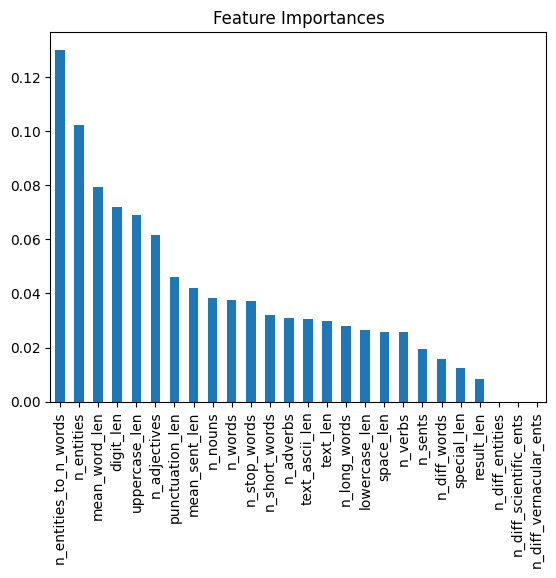

In [406]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importances")
plt.show()

In [420]:
y_pred = []
y_test = []

df = pd.read_excel("44_Abstracts.xlsx", skiprows=[0])
for i, abstract in enumerate(df.Abstract):
    clear_cache()
    doc = nlp(abstract)
    
    X = pd.DataFrame([get_parameters(doc)])
    X = preprocess_log10(X)
    X[['mean_word_len', 'mean_sent_len']] = scaler.transform(X[['mean_word_len', 'mean_sent_len']])
    X = X.iloc[[0]].values
    
    pred = model.predict(X)[0]
    y_pred.append(pred)
    y_test.append(1)
    # y_test.append(int(df.loc[i, "Score"] == 3))

print(classification_report(y_test, y_pred, labels=[0, 1], target_names=['Not TMIM', 'TMIM']))

              precision    recall  f1-score   support

    Not TMIM       0.00      0.00      0.00         0
        TMIM       1.00      0.77      0.87        44

    accuracy                           0.77        44
   macro avg       0.50      0.39      0.44        44
weighted avg       1.00      0.77      0.87        44



In [422]:
len(y_pred) - sum(y_pred)

10